# Level 5: Advanced Analysis and Visualization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv("C:/Users/lavanya/Downloads/Internship_Files/Raw_Dataset.csv")
df=pd.DataFrame(data)
print(df)

        SN  Train_No Station_Code    1A    2A    3A    SL     Station_Name  \
0        1       107          SWV   100   100   100   100     SAWANTWADI R   
1        2       107         THVM   260   228   196   164           THIVIM   
2        3       107         KRMI   345   296   247   198          KARMALI   
3        4       107          MAO   490   412   334   256      MADGOAN JN.   
4        1       108          MAO   100   100   100   100      MADGOAN JN.   
...     ..       ...          ...   ...   ...   ...   ...              ...   
186069   1     22439         NDLS   100   100   100   100        NEW DELHI   
186070   2     22439          UMB  1095   896   697  1095   AMBALA CANT JN   
186071   3     22439          LDH  1660  1348  1036  1660      LUDHIANA JN   
186072   4     22439          JAT  2985  2408  1831  2985       JAMMU TAWI   
186073   5     22439         SVDK  3375  2720  2065  3375  SHMATA VD KATRA   

        Route_Number Arrival_time Departure_Time  Distance  
0 

In [16]:
station_pivot = pd.pivot_table(df,index="Station_Name", values="Train_No", aggfunc=pd.Series.nunique,fill_value=0)
station_pivot

,Train_No
Station_Name,
.BAGHAJATIN,217
ABADA,90
ABHAIPUR,62
ABHANPUR JN.,12
ABHAYAPURI A,6
...,...
ZINDPURA (HA,8
ZORAWARPURA,5
meghpur tito,2


In [17]:
station_route_crosstab = pd.crosstab(df["Station_Name"],df["Route_Number"],values=df["Train_No"],aggfunc=pd.Series.nunique).fillna(0)
station_route_crosstab

Route_Number,1
Station_Name,
.BAGHAJATIN,217
ABADA,90
ABHAIPUR,62
ABHANPUR JN.,12
ABHAYAPURI A,6
...,...
ZINDPURA (HA,8
ZORAWARPURA,5
meghpur tito,2


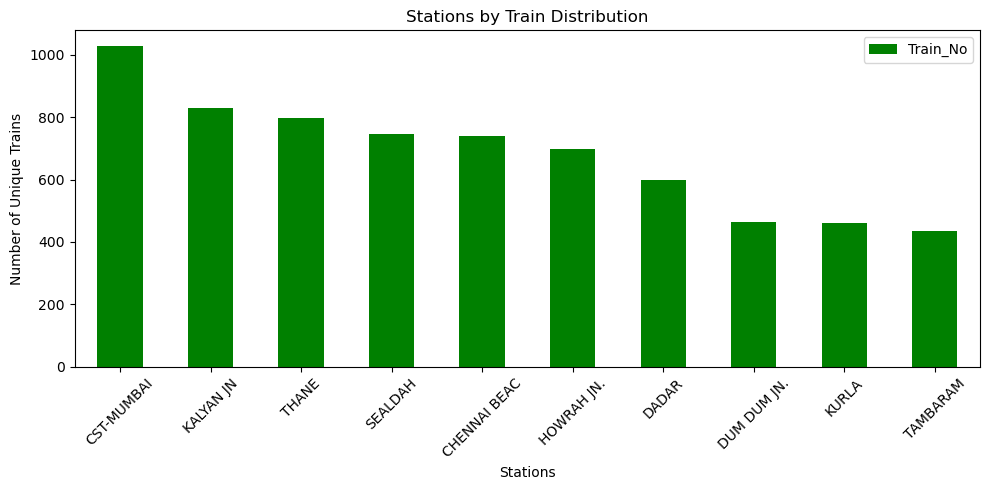

In [26]:
top_station_pivot = station_pivot.sort_values("Train_No", ascending=False).head(10)
top_station_pivot.plot(kind="bar", color="green",figsize=(10, 5))
plt.title("Stations by Train Distribution")
plt.xlabel("Stations")
plt.ylabel("Number of Unique Trains")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
Station_Wise_Train_Frequency = df.groupby("Station_Name")["Train_No"].nunique()
Station_Wise_Train_Frequency = ( df.groupby("Station_Name")["Train_No"].nunique().reset_index(name="Train_Count"))

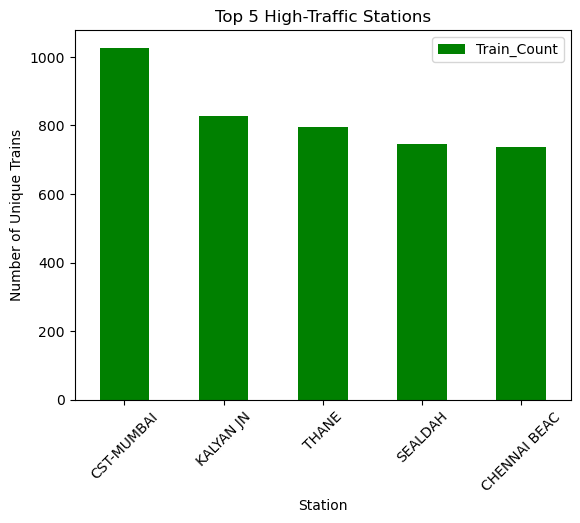

In [25]:
top_stations = Station_Wise_Train_Frequency.sort_values("Train_Count", ascending=False).head(5)
top_stations.plot(x="Station_Name",y="Train_Count",kind="bar",color="Green")
plt.title("Top 5 High-Traffic Stations")
plt.xlabel("Station")
plt.ylabel("Number of Unique Trains")
plt.xticks(rotation=45)
plt.show()

## Task 5.4: Advanced Insights

The pivot and cross tabulation analysis provides a more detailed insights of how train services are distributed across stations and routes. The results show that train activity is not evenly distributed among all stations. A small number of major stations account for a relatively high share of train movements, indicating their importance within the railway network.

The station-wise analysis identifies CST-MUMBAI, KALYAN JN, THANE, SEALDAH, and CHENNAI BEAC as some of the considered as the busiest stations in the dataset. The cross-tabulation further shows that the level of train activity at these stations varies across different route numbers, helping identify which routes contribute more significantly to station traffic.

Overall, the analysis demonstrates that station traffic and route distribution are closely connected. Combining pivot tables with cross-tabulations makes it easier to identify major railway hubs and understand how train services are distributed across different routes.